Saving ngc2420_gaia.csv to ngc2420_gaia (4).csv
Final cluster members: 368


Saving gaia_magnitudes_correct.csv to gaia_magnitudes_correct (1).csv


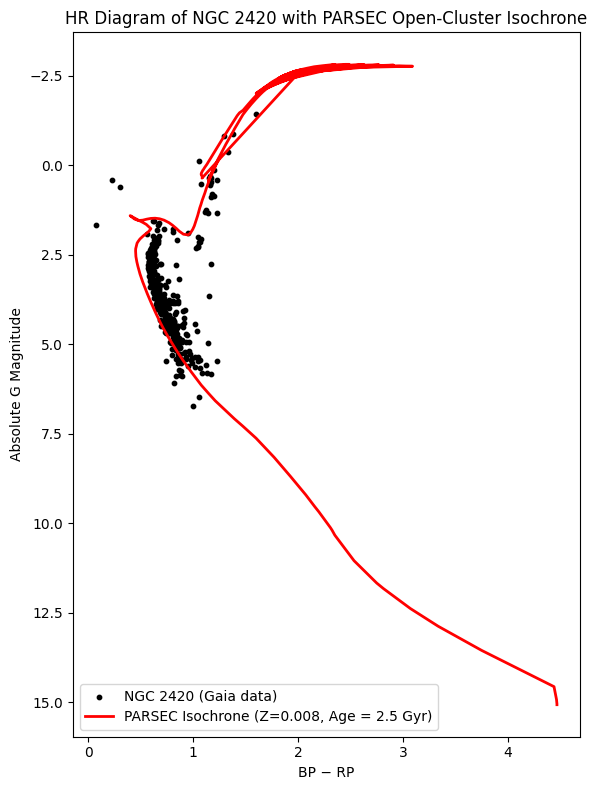

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files



# Upload file
uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]

# Load CSV
df = pd.read_csv(filename)



# =====================================================
# 2. APPLY ALL REQUIRED FILTERS
# p > 0
# sigma_p < 0.2 mas
# p / sigma_p > 5
# 0.3 <= p <= 0.6 mas
# =====================================================
df = df.dropna(subset=[
    "parallax",
    "parallax_error",
    "phot_g_mean_mag",
    "bp_rp"
])

df = df[
    (df["parallax"] > 0) &
    (df["parallax_error"] < 0.2) &
    ((df["parallax"] / df["parallax_error"]) > 5) &
    (df["parallax"] >= 0.3) &
    (df["parallax"] <= 0.6)
]

print("Final cluster members:", len(df))

# =====================================================
# 3. DISTANCE & ABSOLUTE MAGNITUDE
# =====================================================
df["distance_pc"] = 1000.0 / df["parallax"]
df["abs_g_mag"] = (
    df["phot_g_mean_mag"]
    + 5
    - 5 * np.log10(df["distance_pc"])
)

# -----------------------------------------------------
# Upload file
uploadeded = files.upload()

# Get filename
filenamee = list(uploadeded.keys())[0]

# Load CSV
iso = pd.read_csv(filenamee)
iso = iso.dropna(subset=["Gmag", "BPmag", "RPmag"])

iso["bp_rp"] = iso["BPmag"] - iso["RPmag"]

# =====================================================
# 5. FIND MAIN-SEQUENCE TURN-OFF (MSTO)
# =====================================================
mst = df[
    (df["abs_g_mag"] > 2.0) &
    (df["abs_g_mag"] < 3.5)
]

mst_color = mst["bp_rp"].median()
mst_mag   = mst["abs_g_mag"].median()

# =====================================================
# 7. HR DIAGRAM + ISOCHRONE OVERLAY
# =====================================================
plt.figure(figsize=(6, 8))

# Plot observed cluster HR diagram
plt.scatter(
    df["bp_rp"],
    df["abs_g_mag"],
    s=10,
    color="black",
    label="NGC 2420 (Gaia data)"
)

# Plot real PARSEC isochrone (OPEN CLUSTER)
plt.plot(
    iso["bp_rp"],
    iso["Gmag"],
    linewidth=2,
    color="red",
    label="PARSEC Isochrone (Z=0.008, Age = 2.5 Gyr)"
)

plt.gca().invert_yaxis()
plt.xlabel("BP − RP")
plt.ylabel("Absolute G Magnitude")
plt.title("HR Diagram of NGC 2420 with PARSEC Open-Cluster Isochrone")
plt.legend()
plt.tight_layout()
plt.show()

